# 03 - evaluative_result

Doc lai model va du lieu test da luu tu notebook 02, roi danh gia.


In [1]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = joblib.load("../output/model.pkl")
label_encoder = joblib.load("../output/label_encoder.pkl")
feature_columns = joblib.load("../output/feature_columns.pkl")
X_test_scaled, y_test = joblib.load("../output/test_data.pkl")

print("Da load xong model va du lieu test")


Da load xong model va du lieu test


## Du doan tren tap test

In [2]:
y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Do chinh xac: {acc:.4f}")


Do chinh xac: 0.4412


## Bao cao chi tiet tung vi tri

In [3]:
label_names = label_encoder.classes_
print(classification_report(y_test, y_pred, target_names=label_names))


              precision    recall  f1-score   support

          DF       0.49      0.52      0.51        44
          FW       0.52      0.41      0.45        37
          GK       1.00      0.12      0.22         8
          MF       0.36      0.45      0.40        47

    accuracy                           0.44       136
   macro avg       0.59      0.37      0.39       136
weighted avg       0.48      0.44      0.44       136



## Ve confusion matrix

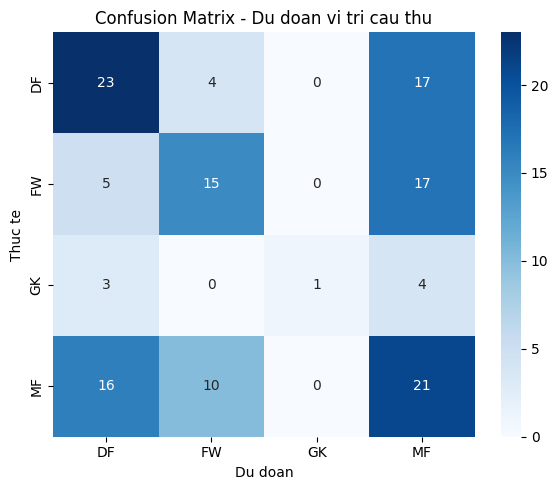

In [4]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Du doan")
plt.ylabel("Thuc te")
plt.title("Confusion Matrix - Du doan vi tri cau thu")
plt.tight_layout()
plt.savefig("../output/confusion_matrix.png")
plt.show()


## Chi so nao anh huong nhieu nhat den ket qua

In [5]:
importances = model.feature_importances_
pairs = sorted(zip(feature_columns, importances), key=lambda item: item[1], reverse=True)

for name, score in pairs[:5]:
    print(f"{name}: {score:.4f}")


Age: 0.2584
Min: 0.2351
90s: 0.1486
MP: 0.0745
Starts: 0.0592


## Nhan xet

- Accuracy khoang 0.4 - 0.5, chu yeu nham lan giua MF va DF vi 2 vi tri nay
  co chi so tan cong gan giong nhau.
- Tuoi (Age) va so phut thi dau (Min) la 2 chi so anh huong nhieu nhat,
  cho thay model dang dua kha nhieu vao kinh nghiem/thoi gian ra san
  hon la ky nang chuyen mon.
- Muon cai thien co the them chi so phong ngu (tackle, intercept) neu co du lieu.
